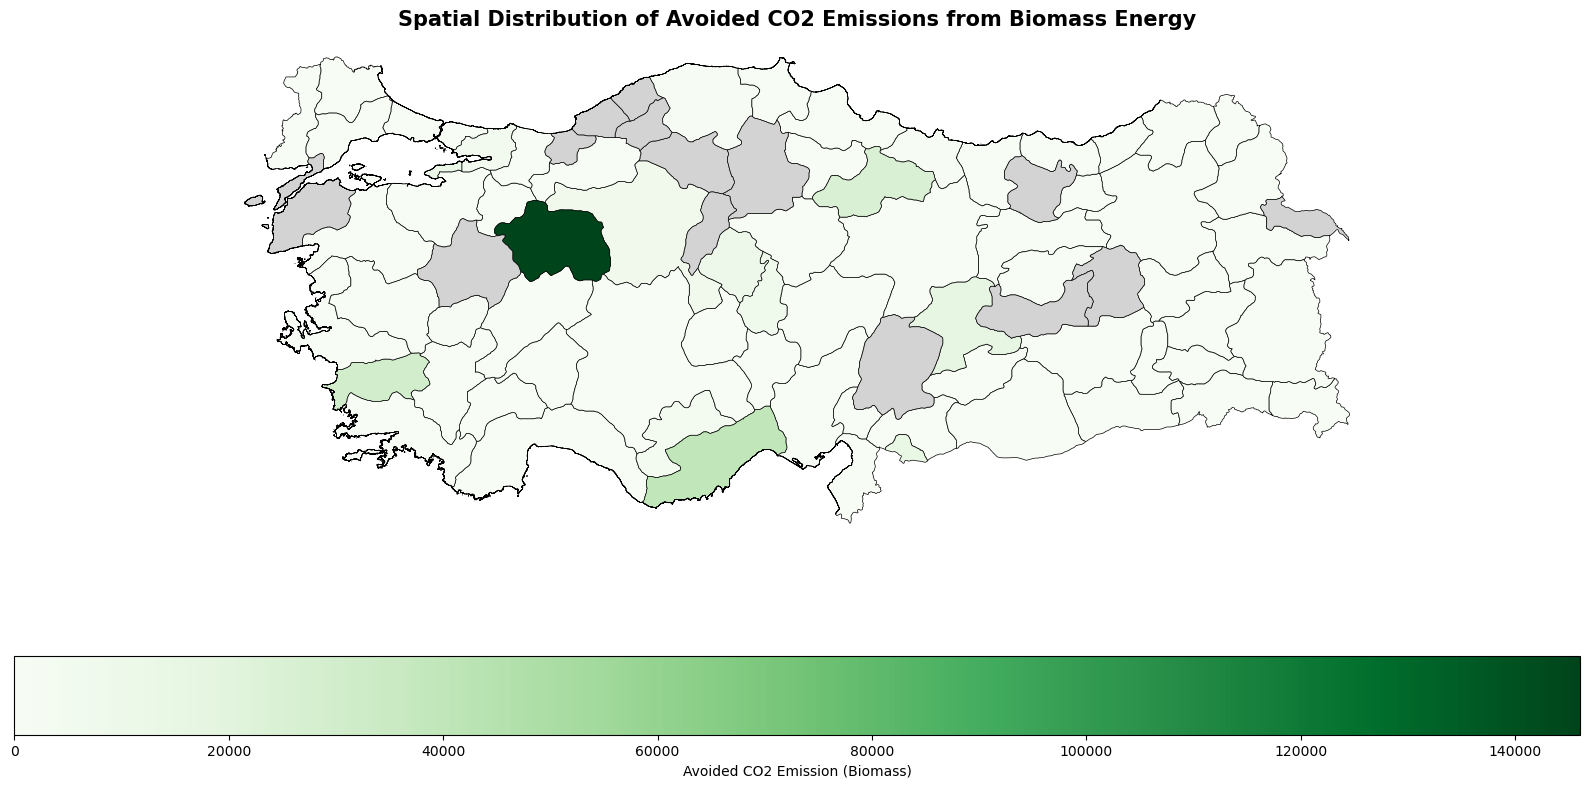

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Dosya Yolları
shp_path = r"C:\Users\W11\dergi2\raw_data\map_data\gadm41_TUR_1.shp"
excel_path = r"C:\Users\W11\dergi2\processed_data\final\final.xlsx"

# 2. Verileri Yükleme
gdf = gpd.read_file(shp_path)
df = pd.read_excel(excel_path)

# 3. Shapefile İl İsimlerini Standartlaştırma (Sizin verdiğiniz liste)
mapping = {
    'Adana': 'ADANA', 'Adiyaman': 'ADIYAMAN', 'Afyon': 'AFYONKARAHİSAR', 
    'Agri': 'AĞRI', 'Aksaray': 'AKSARAY', 'Amasya': 'AMASYA', 
    'Ankara': 'ANKARA', 'Antalya': 'ANTALYA', 'Ardahan': 'ARDAHAN', 
    'Artvin': 'ARTVİN', 'Aydin': 'AYDIN', 'Balikesir': 'BALIKESİR', 
    'Bartin': 'BARTIN', 'Batman': 'BATMAN', 'Bayburt': 'BAYBURT', 
    'Bilecik': 'BİLECİK', 'Bingol': 'BİNGÖL', 'Bitlis': 'BİTLİS', 
    'Bolu': 'BOLU', 'Burdur': 'BURDUR', 'Bursa': 'BURSA', 
    'Denizli': 'DENİZLİ', 'Diyarbakir': 'DİYARBAKIR', 'Duzce': 'DÜZCE', 
    'Edirne': 'EDİRNE', 'Elazig': 'ELAZIĞ', 'Erzincan': 'ERZİNCAN', 
    'Erzurum': 'ERZURUM', 'Eskisehir': 'ESKİŞEHİR', 'Gaziantep': 'GAZİANTEP', 
    'Giresun': 'GİRESUN', 'Gumushane': 'GÜMÜŞHANE', 'Hakkari': 'HAKKARİ', 
    'Hatay': 'HATAY', 'Isparta': 'ISPARTA', 'Istanbul': 'İSTANBUL', 
    'Izmir': 'İZMİR', 'Igdir': 'IĞDIR', 'Kahramanmaras': 'KAHRAMANMARAŞ', 
    'Karabuk': 'KARABÜK', 'Karaman': 'KARAMAN', 'Kars': 'KARS', 
    'Kastamonu': 'KASTAMONU', 'Kayseri': 'KAYSERİ', 'Kilis': 'KİLİS', 
    'Kirikkale': 'KIRIKKALE', 'Kirklareli': 'KIRKLARELİ', 'Kirsehir': 'KIRŞEHİR', 
    'Kocaeli': 'KOCAELİ', 'Konya': 'KONYA', 'Kutahya': 'KÜTAHYA', 
    'Malatya': 'MALATYA', 'Manisa': 'MANİSA', 'Mardin': 'MARDİN', 
    'Mersin': 'MERSİN', 'Mugla': 'MUĞLA', 'Mus': 'MUŞ', 
    'Nevsehir': 'NEVŞEHİR', 'Nigde': 'NİĞDE', 'Ordu': 'ORDU', 
    'Osmaniye': 'OSMANİYE', 'Rize': 'RİZE', 'Sakarya': 'SAKARYA', 
    'Samsun': 'SAMSUN', 'Sanliurfa': 'ŞANLIURFA', 'Siirt': 'SİİRT', 
    'Sinop': 'SİNOP', 'Sirnak': 'ŞIRNAK', 'Sivas': 'SİVAS', 
    'Tekirdag': 'TEKİRDAĞ', 'Tokat': 'TOKAT', 'Trabzon': 'TRABZON', 
    'Tunceli': 'TUNCELİ', 'Usak': 'UŞAK', 'Van': 'VAN', 
    'Yalova': 'YALOVA', 'Yozgat': 'YOZGAT', 'Zonguldak': 'ZONGULDAK', 
    'Canakkale': 'ÇANAKKALE', 'Cankiri': 'ÇANKIRI', 'Corum': 'ÇORUM'
}

# GADM verisindeki İngilizce/hatalı isimleri eşleştirip düzeltiyoruz
# NAME_1 genelde GADM Türkiye verilerinde illerin bulunduğu sütundur
gdf['NAME_1'] = gdf['NAME_1'].map(mapping).fillna(gdf['NAME_1'])

# 4. Excel'deki Plaka (Plate) kodlarını İl isimlerine çevirme
plate_mapping = {
    1: 'ADANA', 2: 'ADIYAMAN', 3: 'AFYONKARAHİSAR', 4: 'AĞRI', 5: 'AMASYA',
    6: 'ANKARA', 7: 'ANTALYA', 8: 'ARTVİN', 9: 'AYDIN', 10: 'BALIKESİR',
    11: 'BİLECİK', 12: 'BİNGÖL', 13: 'BİTLİS', 14: 'BOLU', 15: 'BURDUR',
    16: 'BURSA', 17: 'ÇANAKKALE', 18: 'ÇANKIRI', 19: 'ÇORUM', 20: 'DENİZLİ',
    21: 'DİYARBAKIR', 22: 'EDİRNE', 23: 'ELAZIĞ', 24: 'ERZİNCAN', 25: 'ERZURUM',
    26: 'ESKİŞEHİR', 27: 'GAZİANTEP', 28: 'GİRESUN', 29: 'GÜMÜŞHANE', 30: 'HAKKARİ',
    31: 'HATAY', 32: 'ISPARTA', 33: 'MERSİN', 34: 'İSTANBUL', 35: 'İZMİR',
    36: 'KARS', 37: 'KASTAMONU', 38: 'KAYSERİ', 39: 'KIRKLARELİ', 40: 'KIRŞEHİR',
    41: 'KOCAELİ', 42: 'KONYA', 43: 'KÜTAHYA', 44: 'MALATYA', 45: 'MANİSA',
    46: 'KAHRAMANMARAŞ', 47: 'MARDİN', 48: 'MUĞLA', 49: 'MUŞ', 50: 'NEVŞEHİR',
    51: 'NİĞDE', 52: 'ORDU', 53: 'RİZE', 54: 'SAKARYA', 55: 'SAMSUN',
    56: 'SİİRT', 57: 'SİNOP', 58: 'SİVAS', 59: 'TEKİRDAĞ', 60: 'TOKAT',
    61: 'TRABZON', 62: 'TUNCELİ', 63: 'ŞANLIURFA', 64: 'UŞAK', 65: 'VAN',
    66: 'YOZGAT', 67: 'ZONGULDAK', 68: 'AKSARAY', 69: 'BAYBURT', 70: 'KARAMAN',
    71: 'KIRIKKALE', 72: 'BATMAN', 73: 'ŞIRNAK', 74: 'BARTIN', 75: 'ARDAHAN',
    76: 'IĞDIR', 77: 'YALOVA', 78: 'KARABÜK', 79: 'KİLİS', 80: 'OSMANİYE',
    81: 'DÜZCE'
}
df['Province'] = df['Plate'].map(plate_mapping)

# Veriyi yıllara ve aylara göre değil, sadece illere göre gruplayıp A_Biomass toplamını alıyoruz
df_grouped = df.groupby('Province')['A_Biomass'].sum().reset_index()

# 5. Geometri (Harita) ile Veriyi Birleştirme
# NAME_1 (Shapefile) ve Province (Excel) üzerinden birleşme yapılıyor
merged = gdf.merge(df_grouped, left_on='NAME_1', right_on='Province', how='left')

# 6. Haritayı Çizdirme
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Biyokütle için yeşil tonlarında ('Greens') bir renk paleti seçtik
merged.plot(column='A_Biomass', ax=ax, legend=True,
            cmap='Greens', edgecolor='black', linewidth=0.5,
            missing_kwds={"color": "lightgrey", "label": "Veri Yok"},
            legend_kwds={'label': "Avoided CO2 Emission (Biomass)", 'orientation': "horizontal"})

ax.set_title("Spatial Distribution of Avoided CO2 Emissions from Biomass Energy", fontsize=15, fontweight='bold')
ax.set_axis_off() # Koordinat eksenlerini (enlem/boylam çizgilerini) gizler

plt.tight_layout()
# Haritayı yüksek çözünürlükte kaydetmek için alttaki satırı aktif edebilirsiniz
# plt.savefig(r"C:\Users\W11\dergi2\processed_data\steps\14_map_biomass_avoided_co2.png", dpi=300)
plt.show()

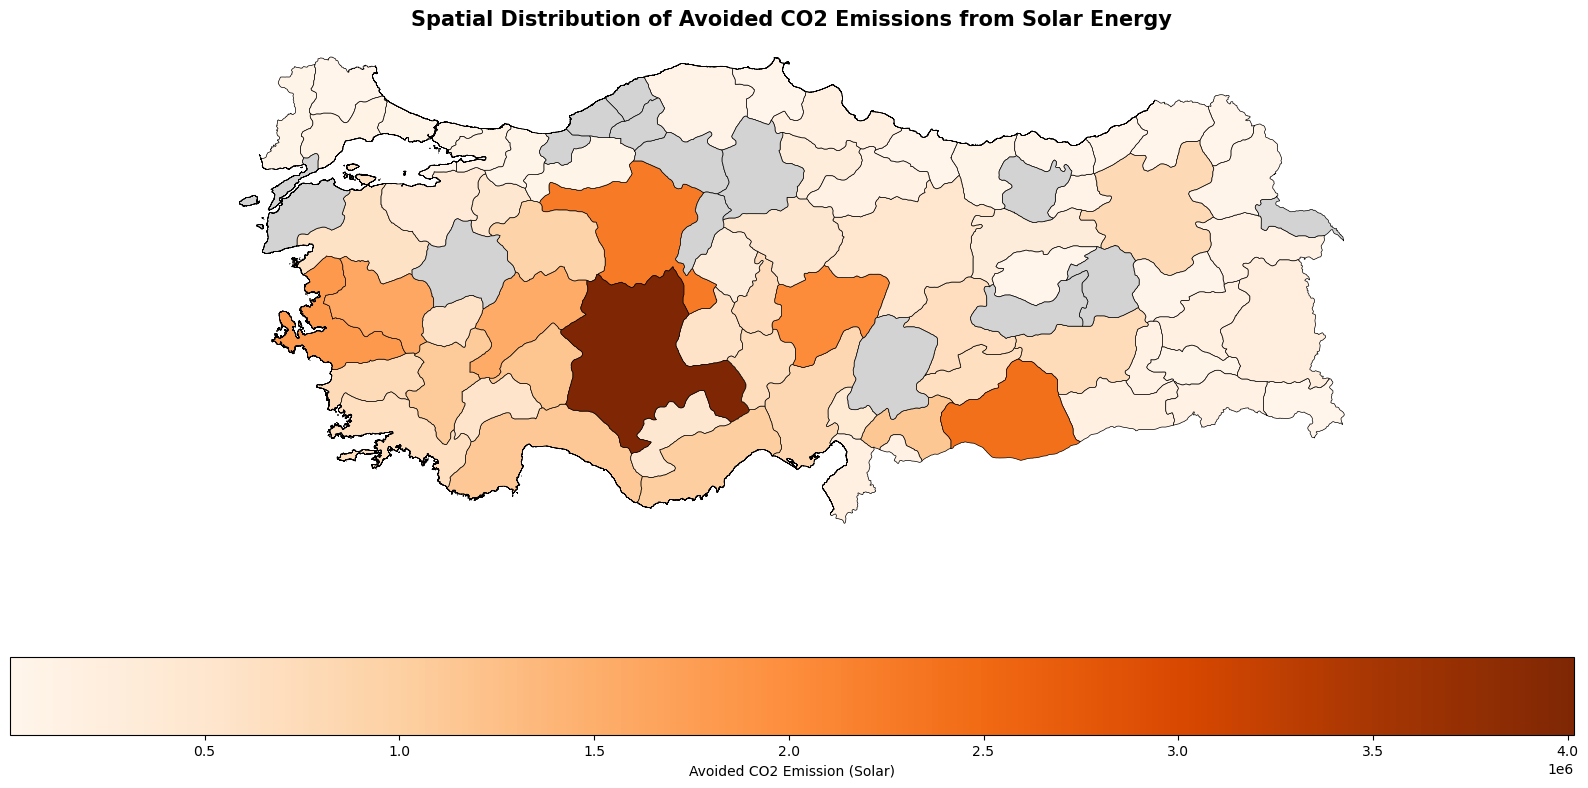

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Dosya Yolları
shp_path = r"C:\Users\W11\dergi2\raw_data\map_data\gadm41_TUR_1.shp"
excel_path = r"C:\Users\W11\dergi2\processed_data\steps\12_calculated_ceei.xlsx"

# 2. Verileri Yükleme
gdf = gpd.read_file(shp_path)
df = pd.read_excel(excel_path)

# 3. Shapefile İl İsimlerini Standartlaştırma
mapping = {
    'Adana': 'ADANA', 'Adiyaman': 'ADIYAMAN', 'Afyon': 'AFYONKARAHİSAR', 
    'Agri': 'AĞRI', 'Aksaray': 'AKSARAY', 'Amasya': 'AMASYA', 
    'Ankara': 'ANKARA', 'Antalya': 'ANTALYA', 'Ardahan': 'ARDAHAN', 
    'Artvin': 'ARTVİN', 'Aydin': 'AYDIN', 'Balikesir': 'BALIKESİR', 
    'Bartin': 'BARTIN', 'Batman': 'BATMAN', 'Bayburt': 'BAYBURT', 
    'Bilecik': 'BİLECİK', 'Bingol': 'BİNGÖL', 'Bitlis': 'BİTLİS', 
    'Bolu': 'BOLU', 'Burdur': 'BURDUR', 'Bursa': 'BURSA', 
    'Denizli': 'DENİZLİ', 'Diyarbakir': 'DİYARBAKIR', 'Duzce': 'DÜZCE', 
    'Edirne': 'EDİRNE', 'Elazig': 'ELAZIĞ', 'Erzincan': 'ERZİNCAN', 
    'Erzurum': 'ERZURUM', 'Eskisehir': 'ESKİŞEHİR', 'Gaziantep': 'GAZİANTEP', 
    'Giresun': 'GİRESUN', 'Gumushane': 'GÜMÜŞHANE', 'Hakkari': 'HAKKARİ', 
    'Hatay': 'HATAY', 'Isparta': 'ISPARTA', 'Istanbul': 'İSTANBUL', 
    'Izmir': 'İZMİR', 'Igdir': 'IĞDIR', 'Kahramanmaras': 'KAHRAMANMARAŞ', 
    'Karabuk': 'KARABÜK', 'Karaman': 'KARAMAN', 'Kars': 'KARS', 
    'Kastamonu': 'KASTAMONU', 'Kayseri': 'KAYSERİ', 'Kilis': 'KİLİS', 
    'Kirikkale': 'KIRIKKALE', 'Kirklareli': 'KIRKLARELİ', 'Kirsehir': 'KIRŞEHİR', 
    'Kocaeli': 'KOCAELİ', 'Konya': 'KONYA', 'Kutahya': 'KÜTAHYA', 
    'Malatya': 'MALATYA', 'Manisa': 'MANİSA', 'Mardin': 'MARDİN', 
    'Mersin': 'MERSİN', 'Mugla': 'MUĞLA', 'Mus': 'MUŞ', 
    'Nevsehir': 'NEVŞEHİR', 'Nigde': 'NİĞDE', 'Ordu': 'ORDU', 
    'Osmaniye': 'OSMANİYE', 'Rize': 'RİZE', 'Sakarya': 'SAKARYA', 
    'Samsun': 'SAMSUN', 'Sanliurfa': 'ŞANLIURFA', 'Siirt': 'SİİRT', 
    'Sinop': 'SİNOP', 'Sirnak': 'ŞIRNAK', 'Sivas': 'SİVAS', 
    'Tekirdag': 'TEKİRDAĞ', 'Tokat': 'TOKAT', 'Trabzon': 'TRABZON', 
    'Tunceli': 'TUNCELİ', 'Usak': 'UŞAK', 'Van': 'VAN', 
    'Yalova': 'YALOVA', 'Yozgat': 'YOZGAT', 'Zonguldak': 'ZONGULDAK', 
    'Canakkale': 'ÇANAKKALE', 'Cankiri': 'ÇANKIRI', 'Corum': 'ÇORUM'
}
gdf['NAME_1'] = gdf['NAME_1'].map(mapping).fillna(gdf['NAME_1'])

# 4. Excel'deki Plaka (Plate) kodlarını İl isimlerine çevirme
plate_mapping = {
    1: 'ADANA', 2: 'ADIYAMAN', 3: 'AFYONKARAHİSAR', 4: 'AĞRI', 5: 'AMASYA',
    6: 'ANKARA', 7: 'ANTALYA', 8: 'ARTVİN', 9: 'AYDIN', 10: 'BALIKESİR',
    11: 'BİLECİK', 12: 'BİNGÖL', 13: 'BİTLİS', 14: 'BOLU', 15: 'BURDUR',
    16: 'BURSA', 17: 'ÇANAKKALE', 18: 'ÇANKIRI', 19: 'ÇORUM', 20: 'DENİZLİ',
    21: 'DİYARBAKIR', 22: 'EDİRNE', 23: 'ELAZIĞ', 24: 'ERZİNCAN', 25: 'ERZURUM',
    26: 'ESKİŞEHİR', 27: 'GAZİANTEP', 28: 'GİRESUN', 29: 'GÜMÜŞHANE', 30: 'HAKKARİ',
    31: 'HATAY', 32: 'ISPARTA', 33: 'MERSİN', 34: 'İSTANBUL', 35: 'İZMİR',
    36: 'KARS', 37: 'KASTAMONU', 38: 'KAYSERİ', 39: 'KIRKLARELİ', 40: 'KIRŞEHİR',
    41: 'KOCAELİ', 42: 'KONYA', 43: 'KÜTAHYA', 44: 'MALATYA', 45: 'MANİSA',
    46: 'KAHRAMANMARAŞ', 47: 'MARDİN', 48: 'MUĞLA', 49: 'MUŞ', 50: 'NEVŞEHİR',
    51: 'NİĞDE', 52: 'ORDU', 53: 'RİZE', 54: 'SAKARYA', 55: 'SAMSUN',
    56: 'SİİRT', 57: 'SİNOP', 58: 'SİVAS', 59: 'TEKİRDAĞ', 60: 'TOKAT',
    61: 'TRABZON', 62: 'TUNCELİ', 63: 'ŞANLIURFA', 64: 'UŞAK', 65: 'VAN',
    66: 'YOZGAT', 67: 'ZONGULDAK', 68: 'AKSARAY', 69: 'BAYBURT', 70: 'KARAMAN',
    71: 'KIRIKKALE', 72: 'BATMAN', 73: 'ŞIRNAK', 74: 'BARTIN', 75: 'ARDAHAN',
    76: 'IĞDIR', 77: 'YALOVA', 78: 'KARABÜK', 79: 'KİLİS', 80: 'OSMANİYE',
    81: 'DÜZCE'
}
df['Province'] = df['Plate'].map(plate_mapping)

# GÜNEŞ ENERJİSİ (A_Solar) İÇİN GRUPLAMA
df_grouped = df.groupby('Province')['A_Solar'].sum().reset_index()

# 5. Geometri (Harita) ile Veriyi Birleştirme
merged = gdf.merge(df_grouped, left_on='NAME_1', right_on='Province', how='left')

# 6. Haritayı Çizdirme
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Güneş için turuncu tonlarında ('Oranges') renk paleti
merged.plot(column='A_Solar', ax=ax, legend=True,
            cmap='Oranges', edgecolor='black', linewidth=0.5,
            missing_kwds={"color": "lightgrey", "label": "Veri Yok"},
            legend_kwds={'label': "Avoided CO2 Emission (Solar)", 'orientation': "horizontal"})

ax.set_title("Spatial Distribution of Avoided CO2 Emissions from Solar Energy", fontsize=15, fontweight='bold')
ax.set_axis_off() 

plt.tight_layout()
# Haritayı kaydetmek için alttaki satırı aktif edebilirsiniz
# plt.savefig(r"C:\Users\W11\dergi2\processed_data\steps\14_map_solar_avoided_co2.png", dpi=300)
plt.show()

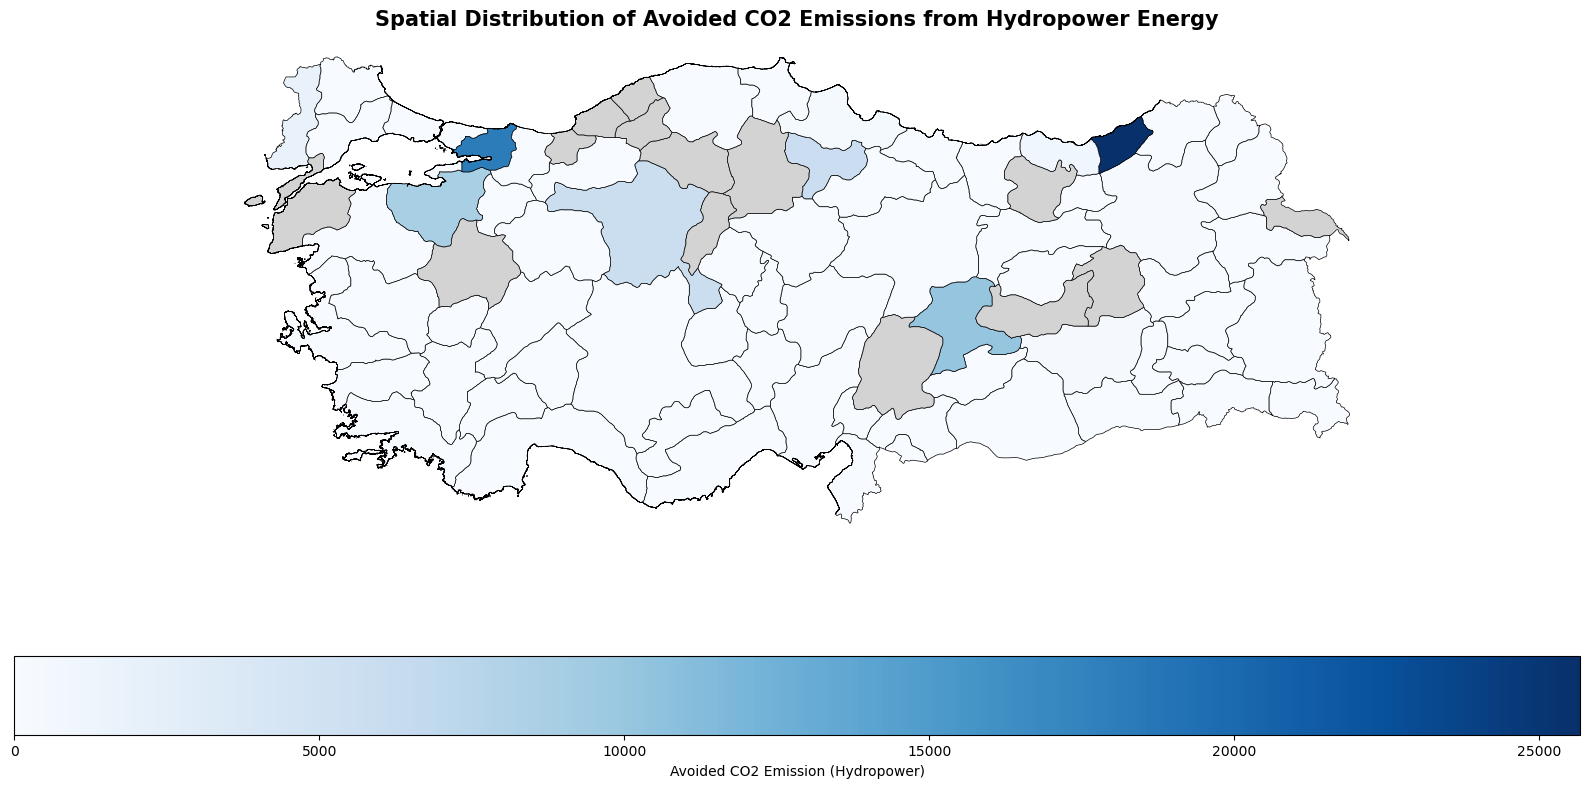

In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Dosya Yolları
shp_path = r"C:\Users\W11\dergi2\raw_data\map_data\gadm41_TUR_1.shp"
excel_path = r"C:\Users\W11\dergi2\processed_data\steps\12_calculated_ceei.xlsx"

# 2. Verileri Yükleme
gdf = gpd.read_file(shp_path)
df = pd.read_excel(excel_path)

# 3. Shapefile İl İsimlerini Standartlaştırma
mapping = {
    'Adana': 'ADANA', 'Adiyaman': 'ADIYAMAN', 'Afyon': 'AFYONKARAHİSAR', 
    'Agri': 'AĞRI', 'Aksaray': 'AKSARAY', 'Amasya': 'AMASYA', 
    'Ankara': 'ANKARA', 'Antalya': 'ANTALYA', 'Ardahan': 'ARDAHAN', 
    'Artvin': 'ARTVİN', 'Aydin': 'AYDIN', 'Balikesir': 'BALIKESİR', 
    'Bartin': 'BARTIN', 'Batman': 'BATMAN', 'Bayburt': 'BAYBURT', 
    'Bilecik': 'BİLECİK', 'Bingol': 'BİNGÖL', 'Bitlis': 'BİTLİS', 
    'Bolu': 'BOLU', 'Burdur': 'BURDUR', 'Bursa': 'BURSA', 
    'Denizli': 'DENİZLİ', 'Diyarbakir': 'DİYARBAKIR', 'Duzce': 'DÜZCE', 
    'Edirne': 'EDİRNE', 'Elazig': 'ELAZIĞ', 'Erzincan': 'ERZİNCAN', 
    'Erzurum': 'ERZURUM', 'Eskisehir': 'ESKİŞEHİR', 'Gaziantep': 'GAZİANTEP', 
    'Giresun': 'GİRESUN', 'Gumushane': 'GÜMÜŞHANE', 'Hakkari': 'HAKKARİ', 
    'Hatay': 'HATAY', 'Isparta': 'ISPARTA', 'Istanbul': 'İSTANBUL', 
    'Izmir': 'İZMİR', 'Igdir': 'IĞDIR', 'Kahramanmaras': 'KAHRAMANMARAŞ', 
    'Karabuk': 'KARABÜK', 'Karaman': 'KARAMAN', 'Kars': 'KARS', 
    'Kastamonu': 'KASTAMONU', 'Kayseri': 'KAYSERİ', 'Kilis': 'KİLİS', 
    'Kirikkale': 'KIRIKKALE', 'Kirklareli': 'KIRKLARELİ', 'Kirsehir': 'KIRŞEHİR', 
    'Kocaeli': 'KOCAELİ', 'Konya': 'KONYA', 'Kutahya': 'KÜTAHYA', 
    'Malatya': 'MALATYA', 'Manisa': 'MANİSA', 'Mardin': 'MARDİN', 
    'Mersin': 'MERSİN', 'Mugla': 'MUĞLA', 'Mus': 'MUŞ', 
    'Nevsehir': 'NEVŞEHİR', 'Nigde': 'NİĞDE', 'Ordu': 'ORDU', 
    'Osmaniye': 'OSMANİYE', 'Rize': 'RİZE', 'Sakarya': 'SAKARYA', 
    'Samsun': 'SAMSUN', 'Sanliurfa': 'ŞANLIURFA', 'Siirt': 'SİİRT', 
    'Sinop': 'SİNOP', 'Sirnak': 'ŞIRNAK', 'Sivas': 'SİVAS', 
    'Tekirdag': 'TEKİRDAĞ', 'Tokat': 'TOKAT', 'Trabzon': 'TRABZON', 
    'Tunceli': 'TUNCELİ', 'Usak': 'UŞAK', 'Van': 'VAN', 
    'Yalova': 'YALOVA', 'Yozgat': 'YOZGAT', 'Zonguldak': 'ZONGULDAK', 
    'Canakkale': 'ÇANAKKALE', 'Cankiri': 'ÇANKIRI', 'Corum': 'ÇORUM'
}
gdf['NAME_1'] = gdf['NAME_1'].map(mapping).fillna(gdf['NAME_1'])

# 4. Excel'deki Plaka (Plate) kodlarını İl isimlerine çevirme
plate_mapping = {
    1: 'ADANA', 2: 'ADIYAMAN', 3: 'AFYONKARAHİSAR', 4: 'AĞRI', 5: 'AMASYA',
    6: 'ANKARA', 7: 'ANTALYA', 8: 'ARTVİN', 9: 'AYDIN', 10: 'BALIKESİR',
    11: 'BİLECİK', 12: 'BİNGÖL', 13: 'BİTLİS', 14: 'BOLU', 15: 'BURDUR',
    16: 'BURSA', 17: 'ÇANAKKALE', 18: 'ÇANKIRI', 19: 'ÇORUM', 20: 'DENİZLİ',
    21: 'DİYARBAKIR', 22: 'EDİRNE', 23: 'ELAZIĞ', 24: 'ERZİNCAN', 25: 'ERZURUM',
    26: 'ESKİŞEHİR', 27: 'GAZİANTEP', 28: 'GİRESUN', 29: 'GÜMÜŞHANE', 30: 'HAKKARİ',
    31: 'HATAY', 32: 'ISPARTA', 33: 'MERSİN', 34: 'İSTANBUL', 35: 'İZMİR',
    36: 'KARS', 37: 'KASTAMONU', 38: 'KAYSERİ', 39: 'KIRKLARELİ', 40: 'KIRŞEHİR',
    41: 'KOCAELİ', 42: 'KONYA', 43: 'KÜTAHYA', 44: 'MALATYA', 45: 'MANİSA',
    46: 'KAHRAMANMARAŞ', 47: 'MARDİN', 48: 'MUĞLA', 49: 'MUŞ', 50: 'NEVŞEHİR',
    51: 'NİĞDE', 52: 'ORDU', 53: 'RİZE', 54: 'SAKARYA', 55: 'SAMSUN',
    56: 'SİİRT', 57: 'SİNOP', 58: 'SİVAS', 59: 'TEKİRDAĞ', 60: 'TOKAT',
    61: 'TRABZON', 62: 'TUNCELİ', 63: 'ŞANLIURFA', 64: 'UŞAK', 65: 'VAN',
    66: 'YOZGAT', 67: 'ZONGULDAK', 68: 'AKSARAY', 69: 'BAYBURT', 70: 'KARAMAN',
    71: 'KIRIKKALE', 72: 'BATMAN', 73: 'ŞIRNAK', 74: 'BARTIN', 75: 'ARDAHAN',
    76: 'IĞDIR', 77: 'YALOVA', 78: 'KARABÜK', 79: 'KİLİS', 80: 'OSMANİYE',
    81: 'DÜZCE'
}
df['Province'] = df['Plate'].map(plate_mapping)

# HİDROELEKTRİK ENERJİSİ (A_Hydropower) İÇİN GRUPLAMA
df_grouped = df.groupby('Province')['A_Hydropower'].sum().reset_index()

# 5. Geometri (Harita) ile Veriyi Birleştirme
merged = gdf.merge(df_grouped, left_on='NAME_1', right_on='Province', how='left')

# 6. Haritayı Çizdirme
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Hidroelektrik için mavi tonlarında ('Blues') renk paleti
merged.plot(column='A_Hydropower', ax=ax, legend=True,
            cmap='Blues', edgecolor='black', linewidth=0.5,
            missing_kwds={"color": "lightgrey", "label": "Veri Yok"},
            legend_kwds={'label': "Avoided CO2 Emission (Hydropower)", 'orientation': "horizontal"})

ax.set_title("Spatial Distribution of Avoided CO2 Emissions from Hydropower Energy", fontsize=15, fontweight='bold')
ax.set_axis_off() 

plt.tight_layout()
# Haritayı kaydetmek için alttaki satırın başındaki '#' işaretini kaldırabilirsiniz
# plt.savefig(r"C:\Users\W11\dergi2\processed_data\steps\14_map_hydropower_avoided_co2.png", dpi=300)
plt.show()

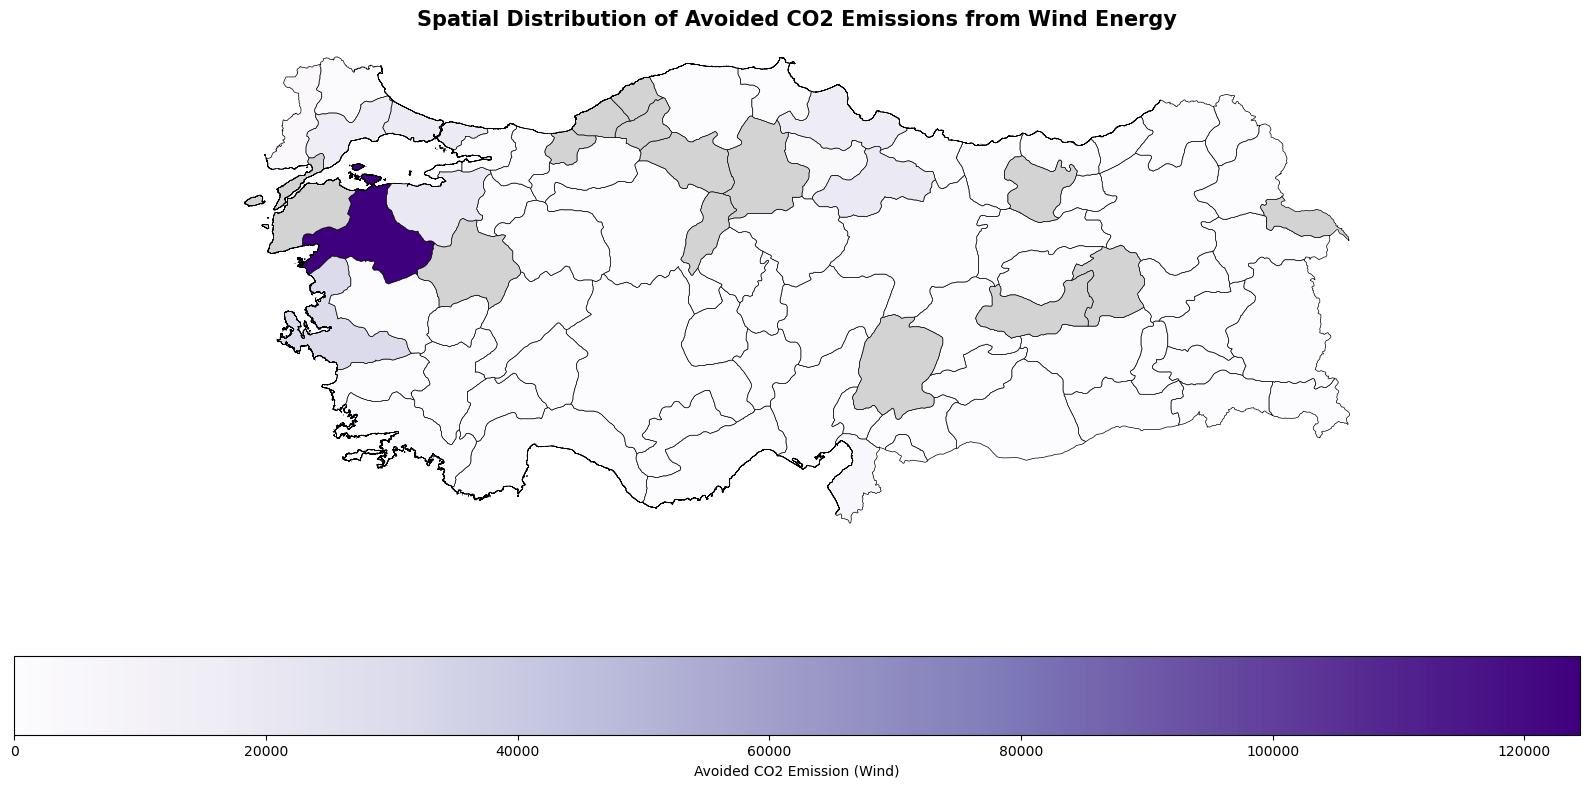

In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Dosya Yolları
shp_path = r"C:\Users\W11\dergi2\raw_data\map_data\gadm41_TUR_1.shp"
excel_path = r"C:\Users\W11\dergi2\processed_data\steps\12_calculated_ceei.xlsx"

# 2. Verileri Yükleme
gdf = gpd.read_file(shp_path)
df = pd.read_excel(excel_path)

# 3. Shapefile İl İsimlerini Standartlaştırma
mapping = {
    'Adana': 'ADANA', 'Adiyaman': 'ADIYAMAN', 'Afyon': 'AFYONKARAHİSAR', 
    'Agri': 'AĞRI', 'Aksaray': 'AKSARAY', 'Amasya': 'AMASYA', 
    'Ankara': 'ANKARA', 'Antalya': 'ANTALYA', 'Ardahan': 'ARDAHAN', 
    'Artvin': 'ARTVİN', 'Aydin': 'AYDIN', 'Balikesir': 'BALIKESİR', 
    'Bartin': 'BARTIN', 'Batman': 'BATMAN', 'Bayburt': 'BAYBURT', 
    'Bilecik': 'BİLECİK', 'Bingol': 'BİNGÖL', 'Bitlis': 'BİTLİS', 
    'Bolu': 'BOLU', 'Burdur': 'BURDUR', 'Bursa': 'BURSA', 
    'Denizli': 'DENİZLİ', 'Diyarbakir': 'DİYARBAKIR', 'Duzce': 'DÜZCE', 
    'Edirne': 'EDİRNE', 'Elazig': 'ELAZIĞ', 'Erzincan': 'ERZİNCAN', 
    'Erzurum': 'ERZURUM', 'Eskisehir': 'ESKİŞEHİR', 'Gaziantep': 'GAZİANTEP', 
    'Giresun': 'GİRESUN', 'Gumushane': 'GÜMÜŞHANE', 'Hakkari': 'HAKKARİ', 
    'Hatay': 'HATAY', 'Isparta': 'ISPARTA', 'Istanbul': 'İSTANBUL', 
    'Izmir': 'İZMİR', 'Igdir': 'IĞDIR', 'Kahramanmaras': 'KAHRAMANMARAŞ', 
    'Karabuk': 'KARABÜK', 'Karaman': 'KARAMAN', 'Kars': 'KARS', 
    'Kastamonu': 'KASTAMONU', 'Kayseri': 'KAYSERİ', 'Kilis': 'KİLİS', 
    'Kirikkale': 'KIRIKKALE', 'Kirklareli': 'KIRKLARELİ', 'Kirsehir': 'KIRŞEHİR', 
    'Kocaeli': 'KOCAELİ', 'Konya': 'KONYA', 'Kutahya': 'KÜTAHYA', 
    'Malatya': 'MALATYA', 'Manisa': 'MANİSA', 'Mardin': 'MARDİN', 
    'Mersin': 'MERSİN', 'Mugla': 'MUĞLA', 'Mus': 'MUŞ', 
    'Nevsehir': 'NEVŞEHİR', 'Nigde': 'NİĞDE', 'Ordu': 'ORDU', 
    'Osmaniye': 'OSMANİYE', 'Rize': 'RİZE', 'Sakarya': 'SAKARYA', 
    'Samsun': 'SAMSUN', 'Sanliurfa': 'ŞANLIURFA', 'Siirt': 'SİİRT', 
    'Sinop': 'SİNOP', 'Sirnak': 'ŞIRNAK', 'Sivas': 'SİVAS', 
    'Tekirdag': 'TEKİRDAĞ', 'Tokat': 'TOKAT', 'Trabzon': 'TRABZON', 
    'Tunceli': 'TUNCELİ', 'Usak': 'UŞAK', 'Van': 'VAN', 
    'Yalova': 'YALOVA', 'Yozgat': 'YOZGAT', 'Zonguldak': 'ZONGULDAK', 
    'Canakkale': 'ÇANAKKALE', 'Cankiri': 'ÇANKIRI', 'Corum': 'ÇORUM'
}
gdf['NAME_1'] = gdf['NAME_1'].map(mapping).fillna(gdf['NAME_1'])

# 4. Excel'deki Plaka (Plate) kodlarını İl isimlerine çevirme
plate_mapping = {
    1: 'ADANA', 2: 'ADIYAMAN', 3: 'AFYONKARAHİSAR', 4: 'AĞRI', 5: 'AMASYA',
    6: 'ANKARA', 7: 'ANTALYA', 8: 'ARTVİN', 9: 'AYDIN', 10: 'BALIKESİR',
    11: 'BİLECİK', 12: 'BİNGÖL', 13: 'BİTLİS', 14: 'BOLU', 15: 'BURDUR',
    16: 'BURSA', 17: 'ÇANAKKALE', 18: 'ÇANKIRI', 19: 'ÇORUM', 20: 'DENİZLİ',
    21: 'DİYARBAKIR', 22: 'EDİRNE', 23: 'ELAZIĞ', 24: 'ERZİNCAN', 25: 'ERZURUM',
    26: 'ESKİŞEHİR', 27: 'GAZİANTEP', 28: 'GİRESUN', 29: 'GÜMÜŞHANE', 30: 'HAKKARİ',
    31: 'HATAY', 32: 'ISPARTA', 33: 'MERSİN', 34: 'İSTANBUL', 35: 'İZMİR',
    36: 'KARS', 37: 'KASTAMONU', 38: 'KAYSERİ', 39: 'KIRKLARELİ', 40: 'KIRŞEHİR',
    41: 'KOCAELİ', 42: 'KONYA', 43: 'KÜTAHYA', 44: 'MALATYA', 45: 'MANİSA',
    46: 'KAHRAMANMARAŞ', 47: 'MARDİN', 48: 'MUĞLA', 49: 'MUŞ', 50: 'NEVŞEHİR',
    51: 'NİĞDE', 52: 'ORDU', 53: 'RİZE', 54: 'SAKARYA', 55: 'SAMSUN',
    56: 'SİİRT', 57: 'SİNOP', 58: 'SİVAS', 59: 'TEKİRDAĞ', 60: 'TOKAT',
    61: 'TRABZON', 62: 'TUNCELİ', 63: 'ŞANLIURFA', 64: 'UŞAK', 65: 'VAN',
    66: 'YOZGAT', 67: 'ZONGULDAK', 68: 'AKSARAY', 69: 'BAYBURT', 70: 'KARAMAN',
    71: 'KIRIKKALE', 72: 'BATMAN', 73: 'ŞIRNAK', 74: 'BARTIN', 75: 'ARDAHAN',
    76: 'IĞDIR', 77: 'YALOVA', 78: 'KARABÜK', 79: 'KİLİS', 80: 'OSMANİYE',
    81: 'DÜZCE'
}
df['Province'] = df['Plate'].map(plate_mapping)

# RÜZGÂR ENERJİSİ (A_Wind) İÇİN GRUPLAMA
df_grouped = df.groupby('Province')['A_Wind'].sum().reset_index()

# 5. Geometri (Harita) ile Veriyi Birleştirme
merged = gdf.merge(df_grouped, left_on='NAME_1', right_on='Province', how='left')

# 6. Haritayı Çizdirme
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Rüzgâr için mor tonlarında ('Purples') renk paleti
merged.plot(column='A_Wind', ax=ax, legend=True,
            cmap='Purples', edgecolor='black', linewidth=0.5,
            missing_kwds={"color": "lightgrey", "label": "Veri Yok"},
            legend_kwds={'label': "Avoided CO2 Emission (Wind)", 'orientation': "horizontal"})

ax.set_title("Spatial Distribution of Avoided CO2 Emissions from Wind Energy", fontsize=15, fontweight='bold')
ax.set_axis_off() 

plt.tight_layout()
# Haritayı kaydetmek için alttaki satırın başındaki '#' işaretini kaldırabilirsiniz
# plt.savefig(r"C:\Users\W11\dergi2\processed_data\steps\14_map_wind_avoided_co2.png", dpi=300)
plt.show()




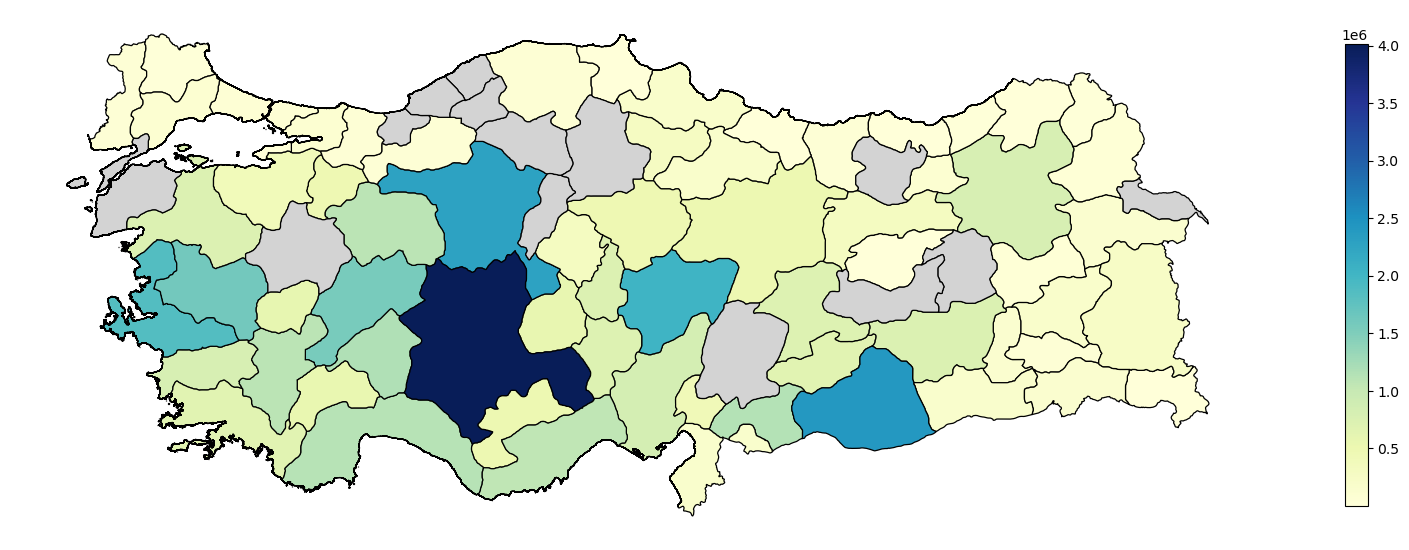

In [27]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Dosya Yolları
shp_path = r"C:\Users\W11\dergi2\raw_data\map_data\gadm41_TUR_1.shp"
excel_path = r"C:\Users\W11\dergi2\processed_data\steps\12_calculated_ceei.xlsx"

# 2. Verileri Yükleme
gdf = gpd.read_file(shp_path)
df = pd.read_excel(excel_path)

# 3. Shapefile İl İsimlerini Standartlaştırma
mapping = {
    'Adana': 'ADANA', 'Adiyaman': 'ADIYAMAN', 'Afyon': 'AFYONKARAHİSAR', 
    'Agri': 'AĞRI', 'Aksaray': 'AKSARAY', 'Amasya': 'AMASYA', 
    'Ankara': 'ANKARA', 'Antalya': 'ANTALYA', 'Ardahan': 'ARDAHAN', 
    'Artvin': 'ARTVİN', 'Aydin': 'AYDIN', 'Balikesir': 'BALIKESİR', 
    'Bartin': 'BARTIN', 'Batman': 'BATMAN', 'Bayburt': 'BAYBURT', 
    'Bilecik': 'BİLECİK', 'Bingol': 'BİNGÖL', 'Bitlis': 'BİTLİS', 
    'Bolu': 'BOLU', 'Burdur': 'BURDUR', 'Bursa': 'BURSA', 
    'Denizli': 'DENİZLİ', 'Diyarbakir': 'DİYARBAKIR', 'Duzce': 'DÜZCE', 
    'Edirne': 'EDİRNE', 'Elazig': 'ELAZIĞ', 'Erzincan': 'ERZİNCAN', 
    'Erzurum': 'ERZURUM', 'Eskisehir': 'ESKİŞEHİR', 'Gaziantep': 'GAZİANTEP', 
    'Giresun': 'GİRESUN', 'Gumushane': 'GÜMÜŞHANE', 'Hakkari': 'HAKKARİ', 
    'Hatay': 'HATAY', 'Isparta': 'ISPARTA', 'Istanbul': 'İSTANBUL', 
    'Izmir': 'İZMİR', 'Igdir': 'IĞDIR', 'Kahramanmaras': 'KAHRAMANMARAŞ', 
    'Karabuk': 'KARABÜK', 'Karaman': 'KARAMAN', 'Kars': 'KARS', 
    'Kastamonu': 'KASTAMONU', 'Kayseri': 'KAYSERİ', 'Kilis': 'KİLİS', 
    'Kirikkale': 'KIRIKKALE', 'Kirklareli': 'KIRKLARELİ', 'Kirsehir': 'KIRŞEHİR', 
    'Kocaeli': 'KOCAELİ', 'Konya': 'KONYA', 'Kutahya': 'KÜTAHYA', 
    'Malatya': 'MALATYA', 'Manisa': 'MANİSA', 'Mardin': 'MARDİN', 
    'Mersin': 'MERSİN', 'Mugla': 'MUĞLA', 'Mus': 'MUŞ', 
    'Nevsehir': 'NEVŞEHİR', 'Nigde': 'NİĞDE', 'Ordu': 'ORDU', 
    'Osmaniye': 'OSMANİYE', 'Rize': 'RİZE', 'Sakarya': 'SAKARYA', 
    'Samsun': 'SAMSUN', 'Sanliurfa': 'ŞANLIURFA', 'Siirt': 'SİİRT', 
    'Sinop': 'SİNOP', 'Sirnak': 'ŞIRNAK', 'Sivas': 'SİVAS', 
    'Tekirdag': 'TEKİRDAĞ', 'Tokat': 'TOKAT', 'Trabzon': 'TRABZON', 
    'Tunceli': 'TUNCELİ', 'Usak': 'UŞAK', 'Van': 'VAN', 
    'Yalova': 'YALOVA', 'Yozgat': 'YOZGAT', 'Zonguldak': 'ZONGULDAK', 
    'Canakkale': 'ÇANAKKALE', 'Cankiri': 'ÇANKIRI', 'Corum': 'ÇORUM'
}
gdf['NAME_1'] = gdf['NAME_1'].map(mapping).fillna(gdf['NAME_1'])

# 4. Excel'deki Plaka (Plate) kodlarını İl isimlerine çevirme
plate_mapping = {
    1: 'ADANA', 2: 'ADIYAMAN', 3: 'AFYONKARAHİSAR', 4: 'AĞRI', 5: 'AMASYA',
    6: 'ANKARA', 7: 'ANTALYA', 8: 'ARTVİN', 9: 'AYDIN', 10: 'BALIKESİR',
    11: 'BİLECİK', 12: 'BİNGÖL', 13: 'BİTLİS', 14: 'BOLU', 15: 'BURDUR',
    16: 'BURSA', 17: 'ÇANAKKALE', 18: 'ÇANKIRI', 19: 'ÇORUM', 20: 'DENİZLİ',
    21: 'DİYARBAKIR', 22: 'EDİRNE', 23: 'ELAZIĞ', 24: 'ERZİNCAN', 25: 'ERZURUM',
    26: 'ESKİŞEHİR', 27: 'GAZİANTEP', 28: 'GİRESUN', 29: 'GÜMÜŞHANE', 30: 'HAKKARİ',
    31: 'HATAY', 32: 'ISPARTA', 33: 'MERSİN', 34: 'İSTANBUL', 35: 'İZMİR',
    36: 'KARS', 37: 'KASTAMONU', 38: 'KAYSERİ', 39: 'KIRKLARELİ', 40: 'KIRŞEHİR',
    41: 'KOCAELİ', 42: 'KONYA', 43: 'KÜTAHYA', 44: 'MALATYA', 45: 'MANİSA',
    46: 'KAHRAMANMARAŞ', 47: 'MARDİN', 48: 'MUĞLA', 49: 'MUŞ', 50: 'NEVŞEHİR',
    51: 'NİĞDE', 52: 'ORDU', 53: 'RİZE', 54: 'SAKARYA', 55: 'SAMSUN',
    56: 'SİİRT', 57: 'SİNOP', 58: 'SİVAS', 59: 'TEKİRDAĞ', 60: 'TOKAT',
    61: 'TRABZON', 62: 'TUNCELİ', 63: 'ŞANLIURFA', 64: 'UŞAK', 65: 'VAN',
    66: 'YOZGAT', 67: 'ZONGULDAK', 68: 'AKSARAY', 69: 'BAYBURT', 70: 'KARAMAN',
    71: 'KIRIKKALE', 72: 'BATMAN', 73: 'ŞIRNAK', 74: 'BARTIN', 75: 'ARDAHAN',
    76: 'IĞDIR', 77: 'YALOVA', 78: 'KARABÜK', 79: 'KİLİS', 80: 'OSMANİYE',
    81: 'DÜZCE'
}
df['Province'] = df['Plate'].map(plate_mapping)

# --- FİNAL ADIMI: TOPLAM KAÇINILAN CO2 HESAPLAMASI ---
# Tüm yenilenebilir enerji türlerinden elde edilen kazanımları topluyoruz
df['Total_Avoided'] = df['A_Biomass'] + df['A_Solar'] + df['A_Hydropower'] + df['A_Wind']

# Toplam değeri illere göre grupluyoruz
df_grouped = df.groupby('Province')['Total_Avoided'].sum().reset_index()

# 5. Geometri (Harita) ile Veriyi Birleştirme
merged = gdf.merge(df_grouped, left_on='NAME_1', right_on='Province', how='left')

# 6. Haritayı Çizdirme
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

merged.plot(
    column='Total_Avoided',
    ax=ax,
    legend=True,
    cmap='YlGnBu',
    edgecolor='black',
    linewidth=0.9,
    missing_kwds={
        "color": "lightgrey",
        "label": "No Data"
    },
    legend_kwds={
#        'label': "Total Avoided CO2 Emission (All Renewable Sources)",
        'orientation': "vertical",
        'shrink': 0.6
    }
)


# Genel toplam için Sarıdan Laciverte giden ('YlGnBu') renk paleti


# Makale standardında başlık
# ax.set_title("Spatial Distribution of Total Avoided CO2 Emissions in Turkey", fontsize=16, fontweight='bold')
ax.set_axis_off() 

plt.tight_layout()
# Haritayı kaydetmek için aşağıdaki satırı aktif edebilirsiniz
# plt.savefig(r"C:\Users\W11\dergi2\processed_data\steps\15_map_total_avoided_co2.png", dpi=300)
plt.show()

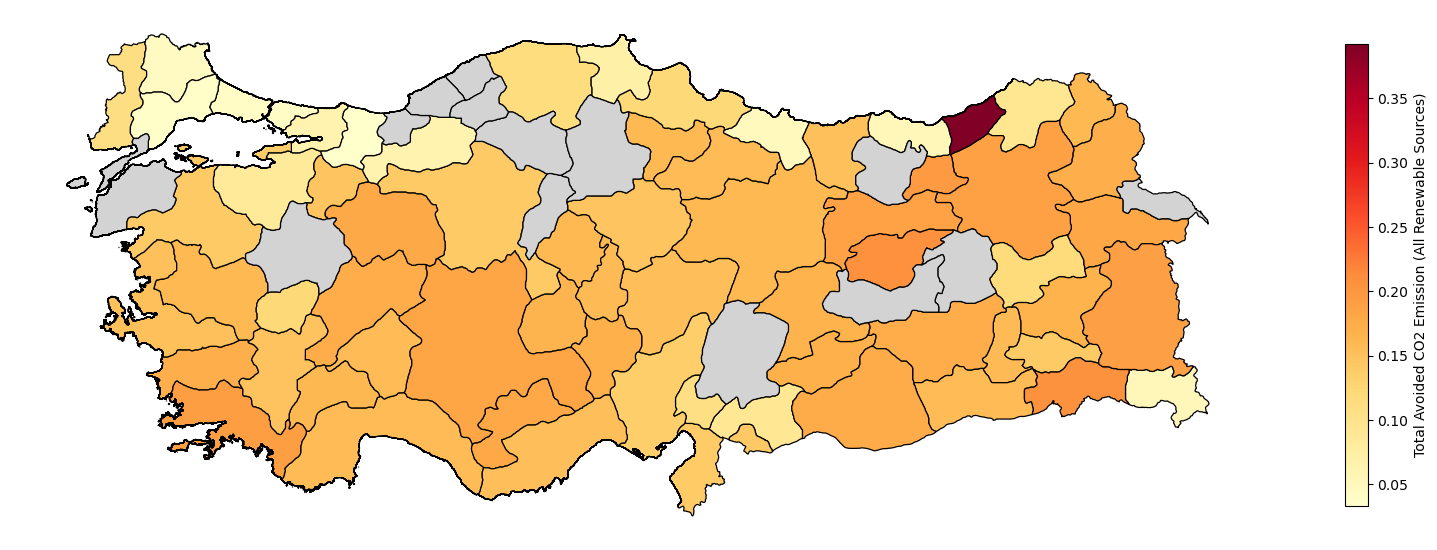

In [34]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Dosya Yolları
shp_path = r"C:\Users\w11\dergi2\raw_data\map_data\gadm41_TUR_1.shp"
excel_path = r"C:\Users\w11\dergi2\processed_data\steps\12_calculated_ceei.xlsx"

# 2. Verileri Yükleme
gdf = gpd.read_file(shp_path)
df = pd.read_excel(excel_path)

# 3. Shapefile İl İsimlerini Standartlaştırma
mapping = {
    'Adana': 'ADANA', 'Adiyaman': 'ADIYAMAN', 'Afyon': 'AFYONKARAHİSAR', 
    'Agri': 'AĞRI', 'Aksaray': 'AKSARAY', 'Amasya': 'AMASYA', 
    'Ankara': 'ANKARA', 'Antalya': 'ANTALYA', 'Ardahan': 'ARDAHAN', 
    'Artvin': 'ARTVİN', 'Aydin': 'AYDIN', 'Balikesir': 'BALIKESİR', 
    'Bartin': 'BARTIN', 'Batman': 'BATMAN', 'Bayburt': 'BAYBURT', 
    'Bilecik': 'BİLECİK', 'Bingol': 'BİNGÖL', 'Bitlis': 'BİTLİS', 
    'Bolu': 'BOLU', 'Burdur': 'BURDUR', 'Bursa': 'BURSA', 
    'Denizli': 'DENİZLİ', 'Diyarbakir': 'DİYARBAKIR', 'Duzce': 'DÜZCE', 
    'Edirne': 'EDİRNE', 'Elazig': 'ELAZIĞ', 'Erzincan': 'ERZİNCAN', 
    'Erzurum': 'ERZURUM', 'Eskisehir': 'ESKİŞEHİR', 'Gaziantep': 'GAZİANTEP', 
    'Giresun': 'GİRESUN', 'Gumushane': 'GÜMÜŞHANE', 'Hakkari': 'HAKKARİ', 
    'Hatay': 'HATAY', 'Isparta': 'ISPARTA', 'Istanbul': 'İSTANBUL', 
    'Izmir': 'İZMİR', 'Igdir': 'IĞDIR', 'Kahramanmaras': 'KAHRAMANMARAŞ', 
    'Karabuk': 'KARABÜK', 'Karaman': 'KARAMAN', 'Kars': 'KARS', 
    'Kastamonu': 'KASTAMONU', 'Kayseri': 'KAYSERİ', 'Kilis': 'KİLİS', 
    'Kirikkale': 'KIRIKKALE', 'Kirklareli': 'KIRKLARELİ', 'Kirsehir': 'KIRŞEHİR', 
    'Kocaeli': 'KOCAELİ', 'Konya': 'KONYA', 'Kutahya': 'KÜTAHYA', 
    'Malatya': 'MALATYA', 'Manisa': 'MANİSA', 'Mardin': 'MARDİN', 
    'Mersin': 'MERSİN', 'Mugla': 'MUĞLA', 'Mus': 'MUŞ', 
    'Nevsehir': 'NEVŞEHİR', 'Nigde': 'NİĞDE', 'Ordu': 'ORDU', 
    'Osmaniye': 'OSMANİYE', 'Rize': 'RİZE', 'Sakarya': 'SAKARYA', 
    'Samsun': 'SAMSUN', 'Sanliurfa': 'ŞANLIURFA', 'Siirt': 'SİİRT', 
    'Sinop': 'SİNOP', 'Sirnak': 'ŞIRNAK', 'Sivas': 'SİVAS', 
    'Tekirdag': 'TEKİRDAĞ', 'Tokat': 'TOKAT', 'Trabzon': 'TRABZON', 
    'Tunceli': 'TUNCELİ', 'Usak': 'UŞAK', 'Van': 'VAN', 
    'Yalova': 'YALOVA', 'Yozgat': 'YOZGAT', 'Zonguldak': 'ZONGULDAK', 
    'Canakkale': 'ÇANAKKALE', 'Cankiri': 'ÇANKIRI', 'Corum': 'ÇORUM'
}
gdf['NAME_1'] = gdf['NAME_1'].map(mapping).fillna(gdf['NAME_1'])

# 4. Excel'deki Plaka (Plate) kodlarını İl isimlerine çevirme
plate_mapping = {
    1: 'ADANA', 2: 'ADIYAMAN', 3: 'AFYONKARAHİSAR', 4: 'AĞRI', 5: 'AMASYA',
    6: 'ANKARA', 7: 'ANTALYA', 8: 'ARTVİN', 9: 'AYDIN', 10: 'BALIKESİR',
    11: 'BİLECİK', 12: 'BİNGÖL', 13: 'BİTLİS', 14: 'BOLU', 15: 'BURDUR',
    16: 'BURSA', 17: 'ÇANAKKALE', 18: 'ÇANKIRI', 19: 'ÇORUM', 20: 'DENİZLİ',
    21: 'DİYARBAKIR', 22: 'EDİRNE', 23: 'ELAZIĞ', 24: 'ERZİNCAN', 25: 'ERZURUM',
    26: 'ESKİŞEHİR', 27: 'GAZİANTEP', 28: 'GİRESUN', 29: 'GÜMÜŞHANE', 30: 'HAKKARİ',
    31: 'HATAY', 32: 'ISPARTA', 33: 'MERSİN', 34: 'İSTANBUL', 35: 'İZMİR',
    36: 'KARS', 37: 'KASTAMONU', 38: 'KAYSERİ', 39: 'KIRKLARELİ', 40: 'KIRŞEHİR',
    41: 'KOCAELİ', 42: 'KONYA', 43: 'KÜTAHYA', 44: 'MALATYA', 45: 'MANİSA',
    46: 'KAHRAMANMARAŞ', 47: 'MARDİN', 48: 'MUĞLA', 49: 'MUŞ', 50: 'NEVŞEHİR',
    51: 'NİĞDE', 52: 'ORDU', 53: 'RİZE', 54: 'SAKARYA', 55: 'SAMSUN',
    56: 'SİİRT', 57: 'SİNOP', 58: 'SİVAS', 59: 'TEKİRDAĞ', 60: 'TOKAT',
    61: 'TRABZON', 62: 'TUNCELİ', 63: 'ŞANLIURFA', 64: 'UŞAK', 65: 'VAN',
    66: 'YOZGAT', 67: 'ZONGULDAK', 68: 'AKSARAY', 69: 'BAYBURT', 70: 'KARAMAN',
    71: 'KIRIKKALE', 72: 'BATMAN', 73: 'ŞIRNAK', 74: 'BARTIN', 75: 'ARDAHAN',
    76: 'IĞDIR', 77: 'YALOVA', 78: 'KARABÜK', 79: 'KİLİS', 80: 'OSMANİYE',
    81: 'DÜZCE'
}
df['Province'] = df['Plate'].map(plate_mapping)

# --- FİNAL ADIMI: CEEI HESAPLAMASI (ORTALAMA ALARAK) ---
# CEEI bir endeks olduğu için illerin 5 yıllık periyottaki ortalama (mean) skorunu alıyoruz
df_grouped = df.groupby('Province')['CEEI'].mean().reset_index()

# 5. Geometri (Harita) ile Veriyi Birleştirme
merged = gdf.merge(df_grouped, left_on='NAME_1', right_on='Province', how='left')

# 6. Haritayı Çizdirme
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

merged.plot(
    column='CEEI',
    ax=ax,
    legend=True,
    cmap='YlOrRd',
    edgecolor='black',
    linewidth=0.9,
    missing_kwds={
        "color": "lightgrey",
        "label": "No Data"
    },
    legend_kwds={
        'label': "Total Avoided CO2 Emission (All Renewable Sources)",
        'orientation': "vertical",
        'shrink': 0.6
    }
)

"""

# CEEI Skorları için Sarıdan Koyu Kırmızıya/Bordoya giden ('YlOrRd') renk paleti
merged.plot(column='CEEI', ax=ax, legend=True,
            cmap='YlOrRd', edgecolor='black', linewidth=0.5,
            missing_kwds={"color": "lightgrey", "label": "Veri Yok"},
            legend_kwds={'label': "Clean Energy Equity Index (CEEI) Score", 'orientation': "horizontal"})
"""
# Makale standardında başlık
# ax.set_title("Spatial Distribution of Clean Energy Equity Index (CEEI) in Turkey", fontsize=16, fontweight='bold')
ax.set_axis_off() 

plt.tight_layout()
# Haritayı kaydetmek için aşağıdaki satırın başındaki '#' işaretini kaldırabilirsin
# plt.savefig(r"C:\Users\W11\dergi2\processed_data\steps\16_map_ceei.png", dpi=300)
plt.show()

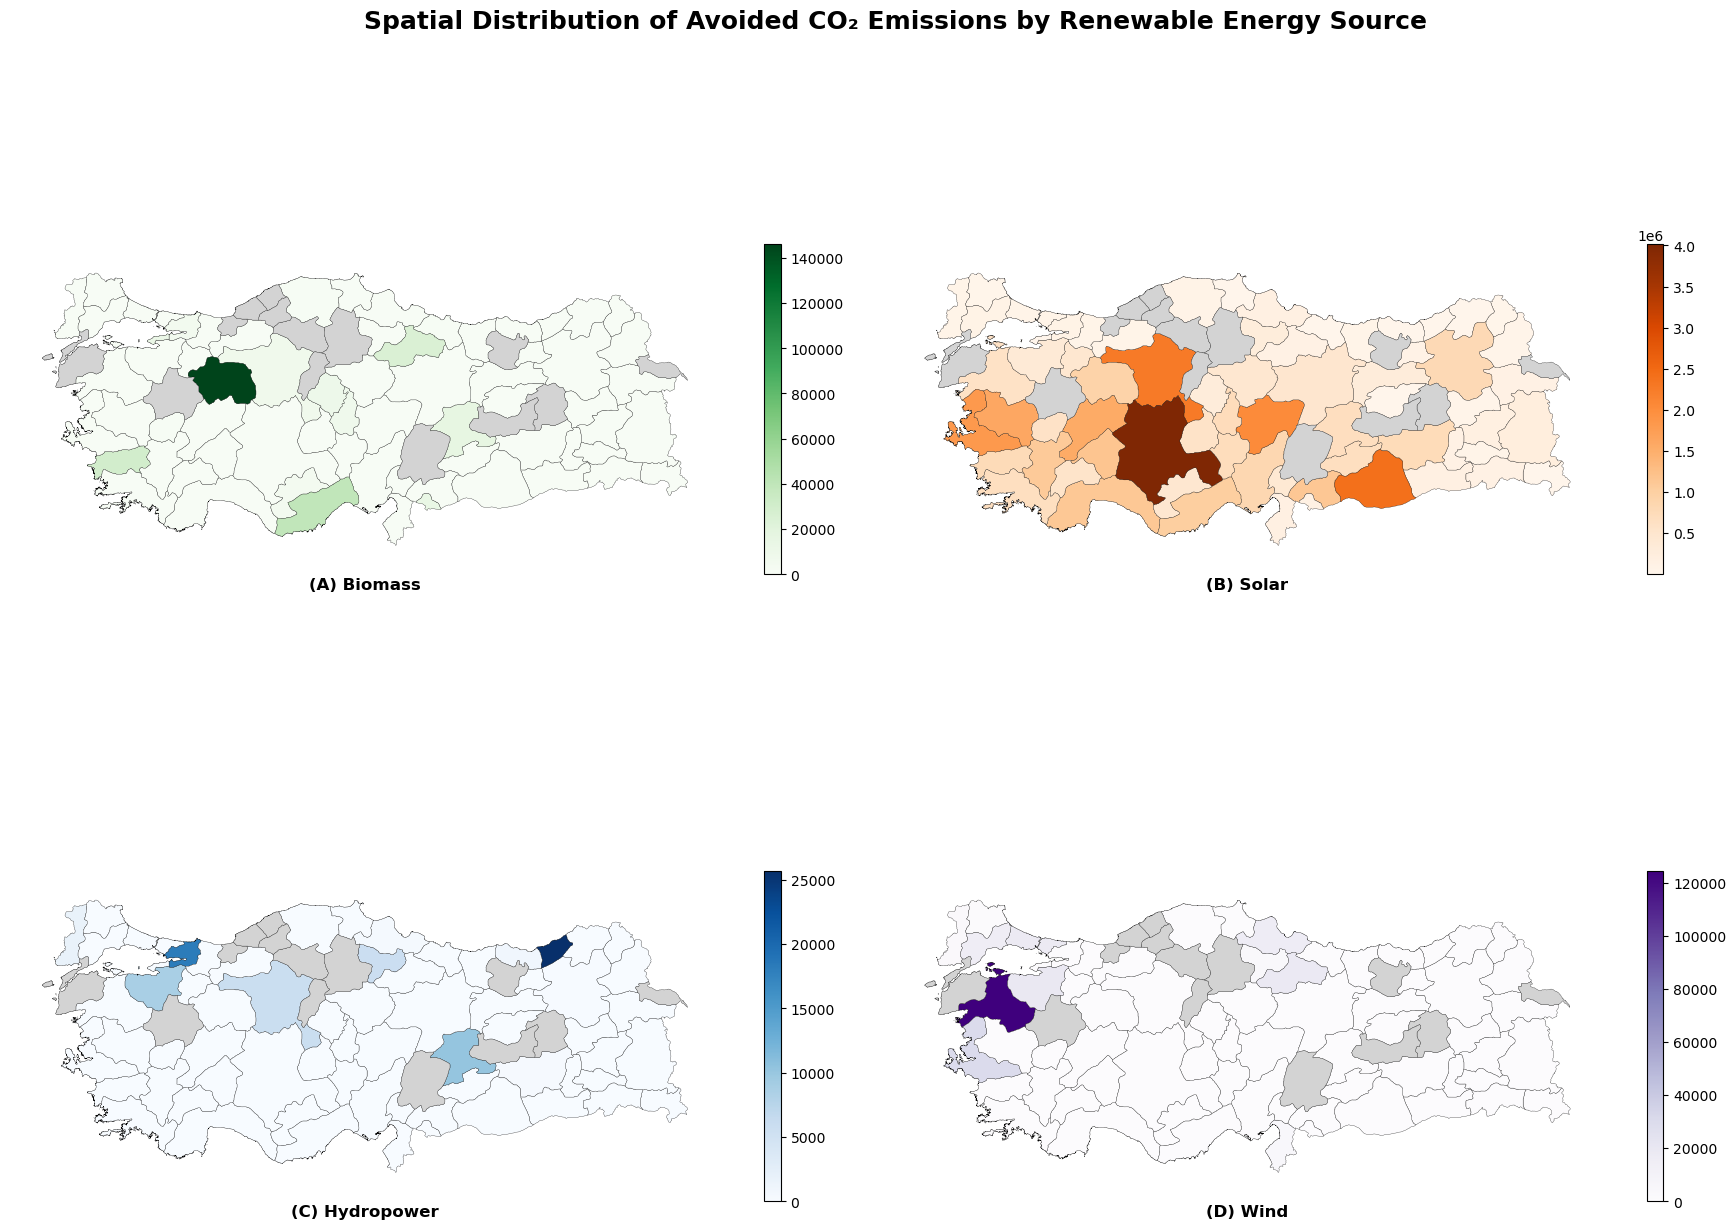

In [18]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ==================================================
# 1. Dosyaları Oku
# ==================================================
shp_path = r"C:\Users\W11\dergi2\raw_data\map_data\gadm41_TUR_1.shp"
excel_path = r"C:\Users\W11\dergi2\processed_data\steps\12_calculated_ceei.xlsx"

gdf = gpd.read_file(shp_path)
df = pd.read_excel(excel_path)

# ==================================================
# 2. İsim Dönüşümleri
# ==================================================

# BURAYA mapping sözlüğünüzü yapıştırın
gdf["NAME_1"] = gdf["NAME_1"].map(mapping).fillna(gdf["NAME_1"])

# BURAYA plate_mapping sözlüğünüzü yapıştırın
df["Province"] = df["Plate"].map(plate_mapping)

# ==================================================
# 3. Harita Ayarları
# ==================================================

maps = [
    ("A_Biomass", "Greens", "(A) Biomass"),
    ("A_Solar", "Oranges", "(B) Solar"),
    ("A_Hydropower", "Blues", "(C) Hydropower"),
    ("A_Wind", "Purples", "(D) Wind")
]

# ==================================================
# 4. Şekil Oluştur
# ==================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, (column, cmap, label) in zip(axes.flatten(), maps):

    # İl bazında toplama
    grouped = (
        df.groupby("Province")[column]
        .sum()
        .reset_index()
    )

    merged = gdf.merge(
        grouped,
        left_on="NAME_1",
        right_on="Province",
        how="left"
    )

    merged.plot(
        column=column,
        cmap=cmap,
        ax=ax,
        legend=True,
        edgecolor="black",
        linewidth=0.2,
        missing_kwds={
            "color": "lightgrey",
            "label": "No Data"
        },
        legend_kwds={
            "shrink": 0.5,
            "orientation": "vertical"
        }
    )

    ax.set_axis_off()

    # Haritanın altına yazı ekle
    ax.text(
        0.5,
        -0.06,
        label,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=12,
        fontweight="bold"
    )

# ==================================================
# 5. Genel Başlık
# ==================================================

fig.suptitle(
    "Spatial Distribution of Avoided CO₂ Emissions by Renewable Energy Source",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.subplots_adjust(
    top=0.93,
    hspace=-0.05
)


# ==================================================
# 6. Kaydet
# ==================================================

# plt.savefig(
#     r"C:\Users\W11\dergi2\processed_data\steps\14_all_maps.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()